# Baltic-1977 → EVRF2019 at the Kakhovka gauges

Phase 2a gave an **empirical vertical alignment constant** per post,
$C \approx 12.36$ m, i.e. $C - 12.00 = +0.36$ m against the nominal gauge zero.
That number lumped the datum difference together with the gauge-zero error and
model bias.

Ukraine has an **official transformation** — EPSG:9902, *Baltic 1977 height to
EVRF2019 height* — which is a **grid**, not a constant: mean +0.151 m, range
+0.079…+0.285 m, SD 0.034 m over 154 defining points. Stopkhai et al. (2026) build
the same transfer from UKG2017 + `EVRF2019zero_AMST` and confirm a grid is required.

So we can finally split:

$$\underbrace{C-\text{zero}_{nom}}_{\Delta_{emp}}=
\underbrace{\Delta_{EPSG9902}(\varphi,\lambda)}_{\text{official}}
+\underbrace{\delta_{unexplained}}_{\text{zero err}+\text{EGG2015}+\text{ATL13}}$$

## 1 · Getting the grid

**PROJ defines the operation but ships no grid for it.** `ua_2019z.asc` is marked
`open_license=False`, `direct_download=False`, with no URL, and the PROJ CDN carries
no Ukrainian grids — so PROJ reports EPSG:9902 as `available: False`. What PROJ can
still offer between these CRSs then degrades to a **ballpark (null)** transformation
that silently returns 0 — using it would look like it worked.

The cell below shows exactly that: note that it enumerates
`tg.unavailable_operations`, and the operation *is* there, named and with its
accuracy — only its grid is missing. That distinction matters: once we supply the
grid ourselves, PROJ can run the very same shift (see §2b).

In [1]:
from pyproj.transformer import TransformerGroup
tg = TransformerGroup('EPSG:5705', 'EPSG:9389')   # Baltic 1977 -> EVRF2019
print('available :', [t.description for t in tg.transformers])
for op in tg.unavailable_operations:
    print('unavailable:', op.name)
    for g in op.grids:
        print('   grid', g.short_name, '| available', g.available,
              '| open_license', g.open_license, '| url', repr(g.url))

available : ['Transformation from Baltic 1977 height to EVRF2019 height (ballpark vertical transformation)']
unavailable: Baltic 1977 height to EVRF2019 height (1)
   grid ua_2019z.asc | available False | open_license False | url ''


The same product is published by CRS-EU as *UA_KRON/NH to EVRF2019zero*
(`ua_2019z.asc`), which is what `scripts/datum_comparison.py --download` fetches.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from kakhovka_altimetry import viz, official_datum as od
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.datum import decompose_alignment, decompose_by

cfg = load_config()
ot  = cfg.official_transform
grid = od.load_official_grid(cfg)
print(ot.source)
print(f'extent lon {grid.lons.min():.2f}..{grid.lons.max():.2f}  '
      f'lat {grid.lats.min():.2f}..{grid.lats.max():.2f}  shape {grid.values.shape}')

CRS-EU 'UA_KRON/NH to EVRF2019zero' == EPSG:9902 (ua_2019z.asc)
extent lon 20.20..45.10  lat 40.89..55.59  shape (99, 167)


## 2 · Numerical sanity check — is this file consistent with EPSG:9902?

Before trusting a downloaded file, check it reproduces the published statistics.
**This is a consistency check, not proof of identity.** The published values are
quoted over the transformation's **154-point defining set** while ours are over 3776
interpolated grid nodes, so agreement says the file is *consistent with* the product,
not that it *is* the product — IDW also smooths the extremes, so `max` is reported
but is not decisive. File identity is the SHA-256 recorded in `provenance.json`.

What this check genuinely earns its keep for is catching a wrong, empty or all-zero
grid — the real failure mode here, given the ballpark fallback above.

### 2b · Cross-check against PROJ's own vgridshift

The statistics check above compares summary numbers. This one compares
*implementations*: we hand the exported GeoTIFF back to PROJ as a vertical-offset
grid and let PROJ apply the same shift our sampler does. PROJ identifies such a
grid by its `TYPE` tag and the band description `vertical_offset` — with anything
else it refuses the file outright.

If our ASCII reader, the row-order flip, the cell-centre origin or the sign
convention were wrong, this is where it would show.

In [3]:
import tempfile, pathlib
from pyproj import Transformer
from kakhovka_altimetry.official_datum import to_geotiff

with tempfile.TemporaryDirectory() as td:
    tif = pathlib.Path(td) / "vgrid.tif"
    to_geotiff(grid, tif, cfg, overviews=False)
    tr = Transformer.from_pipeline(f"+proj=vgridshift +grids={tif} +multiplier=1")

    rows = []
    for s in cfg.gauges.stations:
        ours = float(od.correction_at(grid, s.lat, s.lon)[0])
        theirs = tr.transform(s.lon, s.lat, 0.0)[2]
        rows.append({"post": s.name_en, "ours_m": ours, "proj_m": theirs,
                     "delta_um": (ours - theirs) * 1e6})
    cross = pd.DataFrame(rows)

print(f"max |difference| = {cross.delta_um.abs().max():.3f} micrometres")
cross.round({"ours_m": 6, "proj_m": 6, "delta_um": 3})

max |difference| = 0.003 micrometres


,post,ours_m,proj_m,delta_um
0,Rozumivka,0.203588,0.203588,-0.000
1,Plavni,0.189164,0.189164,-0.002
2,Blahovishchenka,0.183360,0.183360,0.001
3,Nikopol,0.171511,0.171511,-0.000
4,Velyka Lepetykha,0.179227,0.179227,0.002
5,Nova Kakhovka,0.215653,0.215653,0.003


In [4]:
val = od.validate_against_published(grid, cfg)
print(od.format_validation(val))

numerical sanity check vs the published EPSG:9902 metadata (consistency, not file identity; published stats over 154 determination points)
grid nodes (valid): 3776  [matches the published node count]
stat          grid   published     delta   decisive
mean_m       0.145       0.151    -0.006   yes
min_m        0.081       0.079    +0.002   yes
max_m        0.251       0.285    -0.034   no
sd_m         0.031       0.034    -0.003   yes
sanity check: PASS (tolerance 0.020 m on the decisive statistics; identity is established by the SHA-256 in provenance.json, not here)


The valid-node count matches the figure published by Stopkhai et al. exactly,
and mean / min / SD agree to a few millimetres. This is the right grid.

## 3 · The correction at the Kakhovka posts

This is the number the whole question was about — and it is *not* the national
mean, because the correction varies spatially.

In [5]:
summary = pd.read_csv(cfg.tables_dir / 'kakhovka_alignment_by_station.csv')
decomp  = decompose_alignment(summary, grid, cfg)
cols = ['name_en','alignment_constant_m','nominal_zero_m','delta_empirical_m',
        'delta_official_m','delta_unexplained_m','implied_gauge_zero_baltic_m']
decomp[cols].round(3)

,name_en,alignment_constant_m,nominal_zero_m,delta_empirical_m,delta_official_m,delta_unexplained_m,implied_gauge_zero_baltic_m
0,Nova Kakhovka,12.343,12.0,0.343,0.216,0.128,12.128
1,Velyka Lepetykha,12.369,12.0,0.369,0.179,0.189,12.189
2,Nikopol,12.379,12.0,0.379,0.172,0.208,12.208
3,Blahovishchenka,12.333,12.0,0.333,0.183,0.150,12.150
4,Plavni,12.406,12.0,0.406,0.189,0.217,12.217
5,Rozumivka,12.350,12.0,0.350,0.204,0.146,12.146


In [6]:
d = decomp['delta_official_m']
print(f"official BS-77 -> EVRF2019 at the posts : {d.min():.3f} .. {d.max():.3f} m "
      f"(median {d.median():.3f})")
print(f"national range                          : {ot.published_stats['min_m']:.3f} .. "
      f"{ot.published_stats['max_m']:.3f} m (mean {ot.published_stats['mean_m']:.3f})")
print(f"empirical  C - nominal zero             : {decomp.delta_empirical_m.median():+.3f} m")
print(f"left unexplained                        : {decomp.delta_unexplained_m.median():+.3f} m")

official BS-77 -> EVRF2019 at the posts : 0.172 .. 0.216 m (median 0.186)
national range                          : 0.079 .. 0.285 m (mean 0.151)
empirical  C - nominal zero             : +0.359 m
left unexplained                        : +0.170 m


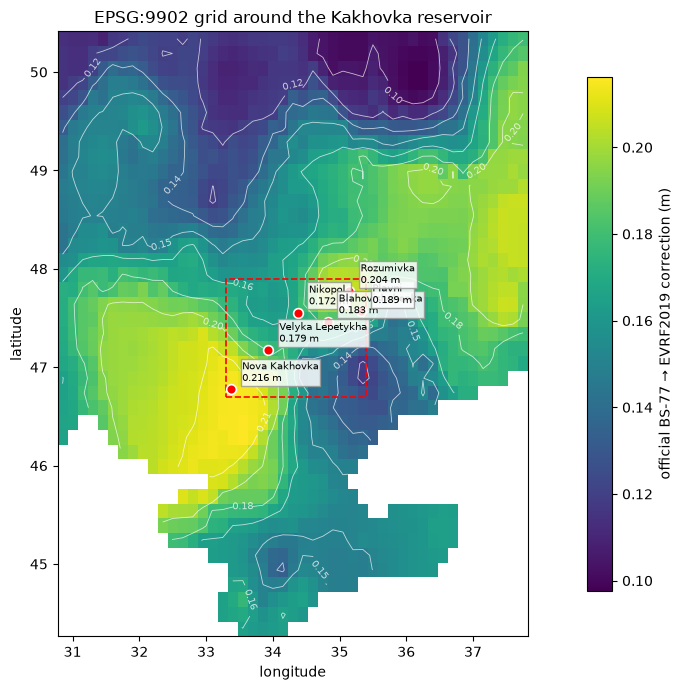

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
viz.official_correction_map(grid, decomp, cfg, ax=ax)
fig.tight_layout()

## 4 · Where the +0.36 m goes

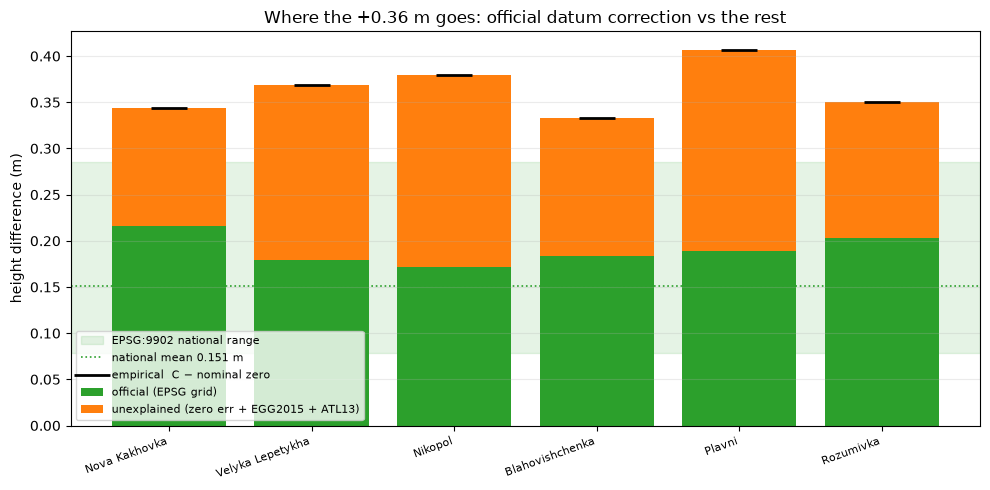

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
viz.datum_budget_bars(decomp, cfg, ax=ax)
fig.tight_layout()

Roughly half of the empirical constant is the **real, officially sanctioned datum
correction**. The rest is not.

### The inversion — a diagnostic, not a result

$$\text{zero}_{implied} = C - \Delta_{EPSG9902} \;\equiv\; \text{zero}_{nominal} + \delta_{unexplained}$$

Note the identity on the right: because the 12.000 m zero is **adopted** rather than
estimated, this column is arithmetically the residual with the nominal zero added
back. It carries **no independent information**.

Read as a counterfactual it still says something useful: *if* the EGG2015 and ATL13
systematics were exactly zero, the posts' true zeros would have to be these values.
Worth checking against a technical passport or a levelled benchmark if one ever
surfaces — but it is **not a measured zero** and must never be reported as one.

In [9]:
decomp[['name_en','nominal_zero_m','implied_gauge_zero_baltic_m',
        'delta_unexplained_m']].round(3)

,name_en,nominal_zero_m,implied_gauge_zero_baltic_m,delta_unexplained_m
0,Nova Kakhovka,12.0,12.128,0.128
1,Velyka Lepetykha,12.0,12.189,0.189
2,Nikopol,12.0,12.208,0.208
3,Blahovishchenka,12.0,12.150,0.150
4,Plavni,12.0,12.217,0.217
5,Rozumivka,12.0,12.146,0.146


## 5 · Consistency check: δ must not depend on the radius

`delta_unexplained_m` is a datum/zero term. If it moved with the search radius
used in Phase 2a, that would mean a bug upstream, not geodesy.

In [10]:
rad = []
for _, r in decomp.iterrows():
    mp = cfg.tables_dir / f"{r['slug']}_local_matchups.csv"
    if not mp.exists():
        continue
    m = pd.read_csv(mp)
    rad.append(decompose_by(m, grid, cfg, ['radius_km'],
                            station_lat=r['lat'], station_lon=r['lon'],
                            nominal_zero_m=r['nominal_zero_m'])
               .assign(name_en=r['name_en']))
by_radius = pd.concat(rad, ignore_index=True)
by_radius.pivot_table(index='name_en', columns='radius_km',
                      values='delta_unexplained_m').round(3)

radius_km,0.5,1.0,2.0,3.0,5.0,10.0
name_en,,,,,,
Blahovishchenka,0.125,0.173,0.150,0.167,0.158,0.156
Nikopol,0.194,0.197,0.208,0.194,0.194,0.186
Nova Kakhovka,NaN,-0.031,0.128,0.138,0.130,0.124
Plavni,0.306,0.298,0.269,0.217,0.232,0.229
Rozumivka,0.132,0.143,0.146,0.146,0.155,0.139
Velyka Lepetykha,NaN,NaN,0.191,0.189,0.197,0.173


In [11]:
thr = cfg.local_alignment.min_matchups_for_confidence
solid = by_radius[by_radius.n_matchups >= thr]
spread = solid.groupby('name_en')['delta_unexplained_m'].agg(lambda s: s.max()-s.min())
print(f'spread across the ladder, rows with n >= {thr} (cm):')
print((spread*100).round(1).to_string())
allrows = by_radius.groupby('name_en')['delta_unexplained_m'].agg(lambda s: s.max()-s.min())
print(f'\nif thin rows are included, up to {(allrows.max()*100):.0f} cm -- '
      f'small-sample noise, not a radius effect')

spread across the ladder, rows with n >= 5 (cm):
name_en
Blahovishchenka     2.3
Nikopol             2.2
Nova Kakhovka       1.4
Plavni              1.4
Rozumivka           1.6
Velyka Lepetykha    2.4

if thin rows are included, up to 17 cm -- small-sample noise, not a radius effect


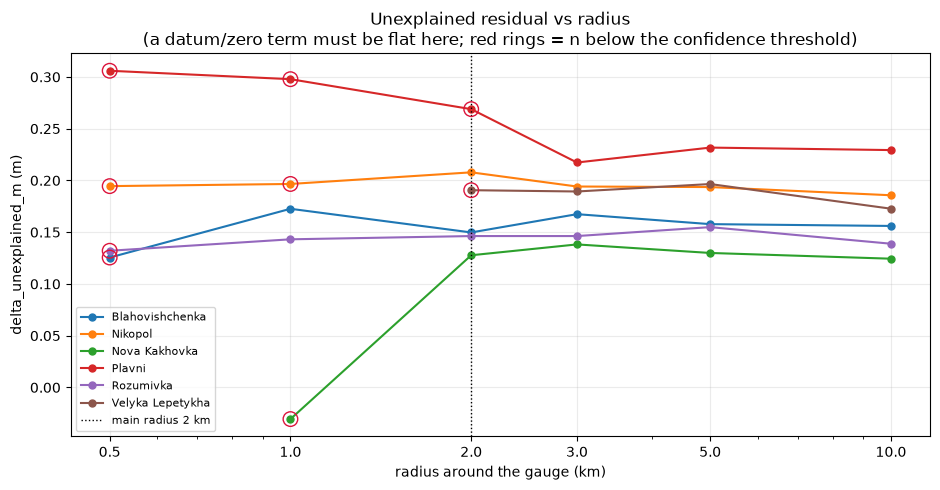

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 5))
viz.unexplained_by_radius(by_radius, cfg, ax=ax)
fig.tight_layout()

## 6 · Error budget

The two frame terms default to **0.0 meaning "not assumed"**, not "known to be
zero". They stay visible so they cannot quietly vanish into the residual.

In [13]:
pd.DataFrame([
    ('delta_official_m (EPSG:9902 grid at the post)', decomp.delta_official_m.median(),
     f"±{ot.published_stats['accuracy_m']:.3f} m stated accuracy"),
    ('evrf2019_minus_evrf2007_m', ot.evrf2019_minus_evrf2007_m,
     'EGG2015 is EVRF2007-consistent; cm level; 0.0 = not assumed'),
    ('tide_system_correction_m', ot.tide_system_correction_m,
     'zero- vs mean-tide; ~2-3 cm at 47.7N; 0.0 = not assumed'),
    ('EGG2015 model error', np.nan, f'±{ot.egg2015_accuracy_m:.2f} m over UA, '
     'sits inside delta_unexplained_m'),
    ('delta_unexplained_m', decomp.delta_unexplained_m.median(),
     'gauge-zero error + EGG2015 error + ATL13 bias'),
], columns=['term', 'value_m', 'note']).round(3)

,term,value_m,note
0,delta_official_m (EPSG:9902 grid at the post),0.186,±0.068 m stated accuracy
1,evrf2019_minus_evrf2007_m,0.000,EGG2015 is EVRF2007-consistent; cm level; 0.0 ...
2,tide_system_correction_m,0.000,zero- vs mean-tide; ~2-3 cm at 47.7N; 0.0 = no...
3,EGG2015 model error,NaN,"±0.10 m over UA, sits inside delta_unexplained_m"
4,delta_unexplained_m,0.170,gauge-zero error + EGG2015 error + ATL13 bias


## 7 · Conclusions

**Determined.** The official Baltic-1977 → EVRF2019 correction *at these
coordinates*, from Ukraine's own transformation grid — around **+0.19 m**, inside
the national range and above the national mean of +0.151 m. That is the answer to
"what is the Baltic→EVRF correction here".

**Not determined.** How the remaining ~**+0.17 m** splits between:

* the **gauge-zero error** — 12.000 m is an *adopted* reservoir-wide constant, not
  six surveyed zeros. `implied_gauge_zero_baltic_m` is a counterfactual diagnostic
  (`nominal_zero + delta_unexplained`), not an estimate of the zero;
* **EGG2015's own model error** over Ukraine (~0.1 m, same order as the residual);
* any **ATL13 systematic bias**.

One surveyed gauge zero, or a GNSS height on a benchmark, closes this. Until then
`delta_unexplained_m` stays exactly that — unexplained, not attributed.

```bash
python scripts/datum_comparison.py --download --maps
```